<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_Lab_05_smoothing%26sharpening_freq_domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab - 05**

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

**Experiment - 01 : Fourier Transform on Synthetic Image**

In [6]:
img = np.zeros((256,256), dtype=np.uint8)

for i in range(0,256,32):
    for j in range(0,256,32):
        if ((i//32 + j//32) % 2 == 0):
            img[i:i+32, j:j+32] = 255

In [7]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

magnitude = 20*np.log(np.abs(fshift)+1)

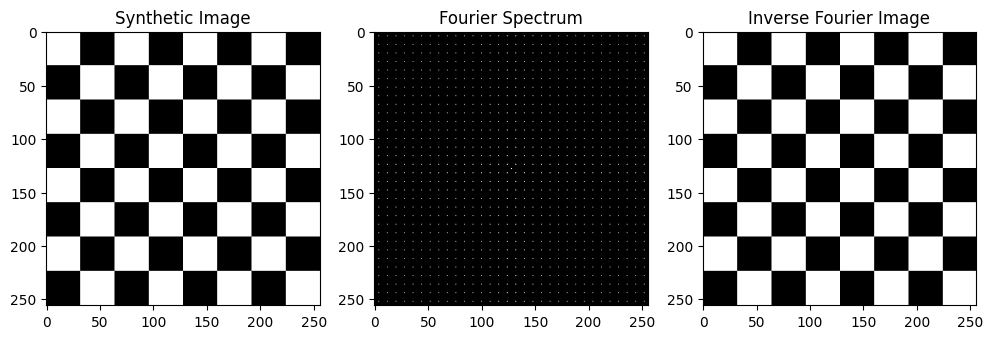

In [8]:
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(img,cmap='gray')
plt.title("Synthetic Image")

plt.subplot(132)
plt.imshow(magnitude,cmap='gray')
plt.title("Fourier Spectrum")

plt.subplot(133)
plt.imshow(img_back,cmap='gray')
plt.title("Inverse Fourier Image")

plt.show()

**Experiment - 02 : Low Pass Filters (Ideal, Butterworth, Gaussian)**

In [10]:
img = cv2.imread('image.jpeg',0)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

In [11]:
def ideal_lpf(shape, cutoff):

    rows, cols = shape
    mask = np.zeros((rows,cols), np.uint8)

    center = (rows//2, cols//2)

    for i in range(rows):
        for j in range(cols):

            dist = np.sqrt((i-center[0])**2 + (j-center[1])**2)

            if dist <= cutoff:
                mask[i,j] = 1

    return mask

In [12]:
def butterworth_lpf(shape, cutoff, n):

    rows, cols = shape
    mask = np.zeros((rows,cols), np.float32)

    center = (rows//2, cols//2)

    for i in range(rows):
        for j in range(cols):

            D = np.sqrt((i-center[0])**2 + (j-center[1])**2)

            mask[i,j] = 1/(1+(D/cutoff)**(2*n))

    return mask

In [13]:
def gaussian_lpf(shape, cutoff):

    rows, cols = shape

    u = np.arange(rows)
    v = np.arange(cols)

    u,v = np.meshgrid(u,v,indexing='ij')

    center_u = rows//2
    center_v = cols//2

    D = np.sqrt((u-center_u)**2 + (v-center_v)**2)

    mask = np.exp(-(D**2)/(2*(cutoff**2)))

    return mask

In [14]:
def apply_filter(mask):

    filtered = fshift * mask

    f_ishift = np.fft.ifftshift(filtered)

    img_back = np.fft.ifft2(f_ishift)

    img_back = np.abs(img_back)

    return img_back

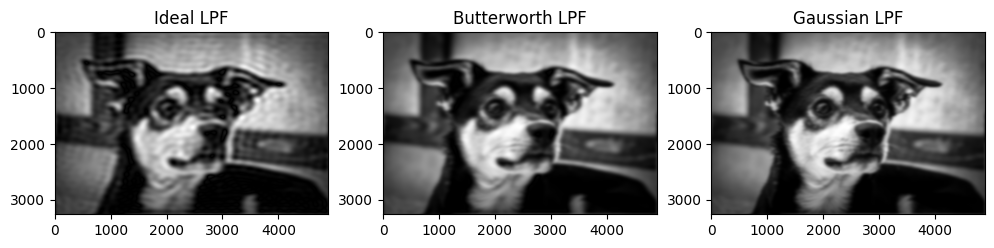

In [15]:
cutoff = 30

ideal = apply_filter(ideal_lpf(img.shape,cutoff))
butter = apply_filter(butterworth_lpf(img.shape,cutoff,2))
gauss = apply_filter(gaussian_lpf(img.shape,cutoff))

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(ideal,cmap='gray')
plt.title("Ideal LPF")

plt.subplot(132)
plt.imshow(butter,cmap='gray')
plt.title("Butterworth LPF")

plt.subplot(133)
plt.imshow(gauss,cmap='gray')
plt.title("Gaussian LPF")

plt.show()

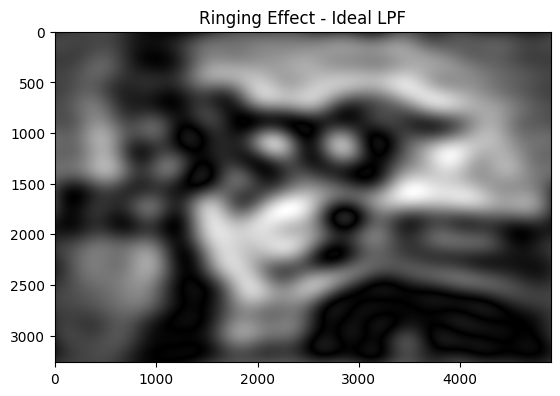

In [16]:
ringing = apply_filter(ideal_lpf(img.shape,10))

plt.imshow(ringing,cmap='gray')
plt.title("Ringing Effect - Ideal LPF")
plt.show()

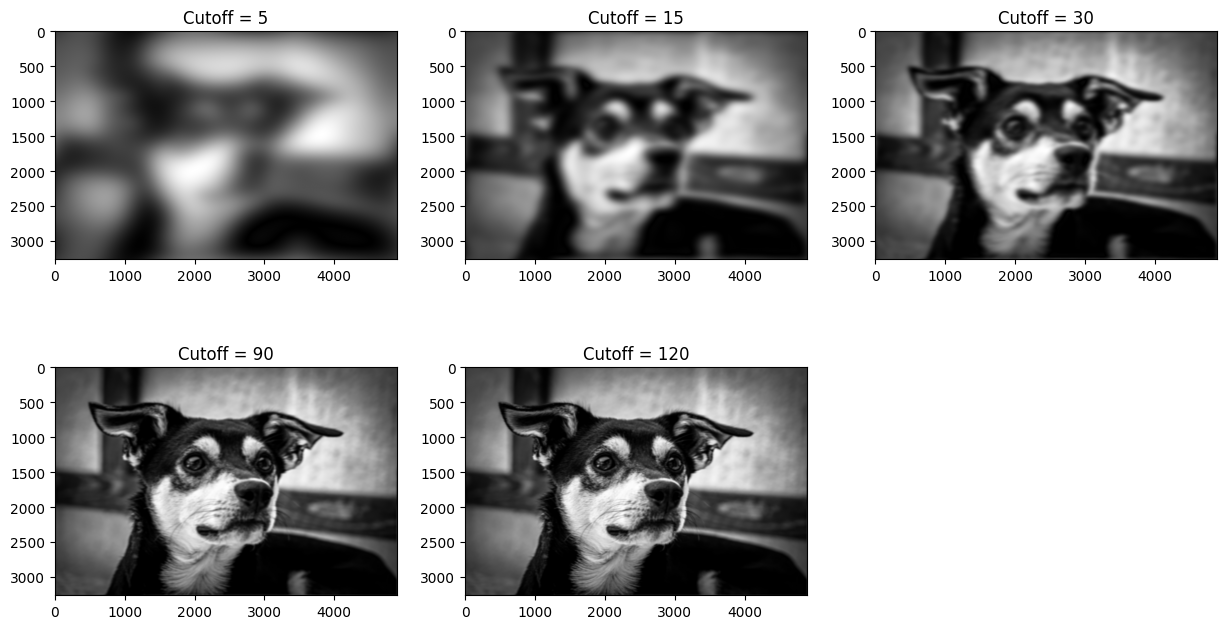

In [17]:
cutoffs = [5,15,30,90,120]

plt.figure(figsize=(15,8))

for i,c in enumerate(cutoffs):

    result = apply_filter(butterworth_lpf(img.shape,c,2))

    plt.subplot(2,3,i+1)
    plt.imshow(result,cmap='gray')
    plt.title("Cutoff = "+str(c))

plt.show()

Experiment - 03 :
High Pass Filters

In [18]:
def ideal_hpf(shape, cutoff):

    rows, cols = shape
    mask = np.ones((rows,cols), np.uint8)

    center = (rows//2, cols//2)

    for i in range(rows):
        for j in range(cols):

            dist = np.sqrt((i-center[0])**2 + (j-center[1])**2)

            if dist <= cutoff:
                mask[i,j] = 0

    return mask

In [19]:
def butterworth_hpf(shape, cutoff, n):

    rows, cols = shape
    mask = np.zeros((rows,cols), np.float32)

    center = (rows//2, cols//2)

    for i in range(rows):
        for j in range(cols):

            D = np.sqrt((i-center[0])**2 + (j-center[1])**2)

            mask[i,j] = 1/(1+(cutoff/D)**(2*n))

    return mask

In [20]:
def gaussian_hpf(shape, cutoff):

    rows, cols = shape

    u = np.arange(rows)
    v = np.arange(cols)

    u,v = np.meshgrid(u,v,indexing='ij')

    center_u = rows//2
    center_v = cols//2

    D = np.sqrt((u-center_u)**2 + (v-center_v)**2)

    mask = 1 - np.exp(-(D**2)/(2*(cutoff**2)))

    return mask

/tmp/ipykernel_642/1005560598.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  mask[i,j] = 1/(1+(cutoff/D)**(2*n))


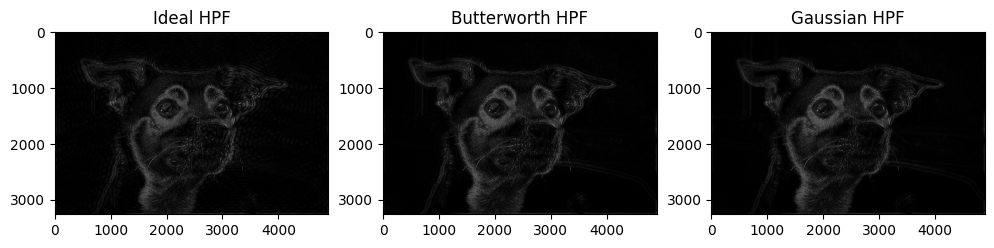

In [21]:
#Compare HPF Filters
cutoff = 30

ideal = apply_filter(ideal_hpf(img.shape,cutoff))
butter = apply_filter(butterworth_hpf(img.shape,cutoff,2))
gauss = apply_filter(gaussian_hpf(img.shape,cutoff))

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(ideal,cmap='gray')
plt.title("Ideal HPF")

plt.subplot(132)
plt.imshow(butter,cmap='gray')
plt.title("Butterworth HPF")

plt.subplot(133)
plt.imshow(gauss,cmap='gray')
plt.title("Gaussian HPF")

plt.show()